In [21]:
import os


os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import keras
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, QuantileTransformer, MinMaxScaler
from pathlib import Path
import seaborn as sns
from natsort import natsorted
from math import floor, log10
from sklearn.model_selection import train_test_split
import shutil

In [22]:
def merge_datasets(datasets):
    """
    Merges a list of datasets (NumPy arrays or Pandas DataFrames) into a single dataset.

    Args:
        datasets: A list of datasets, where each dataset is a NumPy array or a Pandas DataFrame.
                  It is assumed that all datasets have the same number of columns (features).
                  If the datasets have different numbers of columns, the function will still
                  execute, but the results may not be meaningful for subsequent processing.
                  The function does not check for this.

    Returns:
        A single Pandas DataFrame containing all the data from the input datasets.
        Returns an empty DataFrame if the input list is empty.
    """
    if not datasets:
        return pd.DataFrame()  # Return an empty DataFrame if the list is empty

    # Use pd.concat for efficient merging of DataFrames
    merged_data = pd.concat(datasets, axis=0, ignore_index=True)
    return merged_data

def preprocess_data(data, Tr_data, scaler=None):
    """
    Preprocesses the input data by scaling it using StandardScaler.

    Args:
        data: A Pandas DataFrame representing the data to be preprocessed.
        scaler: (Optional) A pre-initialized StandardScaler object. If None,
            a new StandardScaler is initialized and used. If provided,
            the provided scaler is used to transform the data. This is
            useful for applying the same scaling to multiple datasets.
        Tr_data
    Returns:
        A tuple containing:
        - The scaled data as a Pandas DataFrame.
        - The StandardScaler object used for scaling. If a scaler was
          passed in, the same scaler is returned.
    """
    # Ensure we are working with a DataFrame
    
    data = pd.DataFrame(data)
    Tr_data = pd.DataFrame(Tr_data)
    
    if scaler is None:
        scaler = StandardScaler()
        # Fit and transform, then convert back to DataFrame
        scaled_data = scaler.fit_transform(data)
        scaled_data = pd.DataFrame(scaled_data, columns=data.columns)
        # Keep column names
        print(data.columns)
        
        scaled_Tr_data = scaler.transform(Tr_data)
        scaled_Tr_data = pd.DataFrame(scaled_Tr_data, columns=data.columns)
        
    else:
        # Transform using the provided scaler
        scaled_data = scaler.transform(data)
        scaled_data = pd.DataFrame(scaled_data, columns=data.columns)
    return scaled_data, scaled_Tr_data, scaler

def unmerge_datasets(merged_data, original_shapes):
    """
    Unmerges a single dataset into a list of datasets, given the original shapes.

    Args:
        merged_data: A Pandas DataFrame representing the merged dataset.
        original_shapes: A list of tuples, where each tuple represents the shape
            (number of rows, number of columns) of the original dataset.
            The number of columns is not strictly required, but is good practice
            to include. Only the number of rows is used to split the data.
            If the shapes do not add up to the total number of rows in
            `merged_data`, the function will raise a ValueError.

    Returns:
        A list of Pandas DataFrames, where each DataFrame represents an unmerged dataset.
        Returns an empty list if `merged_data` or `original_shapes` is empty.

    Raises:
        ValueError: If the total number of rows in the original shapes do not
            match the number of rows in the merged data.
    """
    if merged_data.empty or not original_shapes:
        return []

    total_rows = sum(rows for rows, _ in original_shapes)
    if total_rows != merged_data.shape[0]:
        raise ValueError(
            f"Total rows in original shapes ({total_rows}) do not match the number of rows in the merged data ({merged_data.shape[0]})"
        )

    unmerged_datasets = []
    start_index = 0
    for rows, _ in original_shapes:
        end_index = start_index + rows
        unmerged_data = merged_data.iloc[start_index:end_index].copy() # Use .iloc for DataFrame slicing and .copy()
        unmerged_datasets.append(unmerged_data)
        start_index = end_index
    return unmerged_datasets


def read_datasets_from_directory(directory, targets, record_shapes=False):
    """
    Reads all CSV files from a specified directory into a list of Pandas DataFrames.

    Args:
        directory: The path to the directory containing the CSV files.
        record_shapes: Boolean indicating whether to record the shapes of the
                       read datasets.  If True, the function also returns a list
                       of the shapes.

    Returns:
        A tuple containing:
        - A list of Pandas DataFrames, where each DataFrame represents a dataset
          read from a CSV file.
        - A list of tuples, where each tuple represents the shape
          (number of rows, number of columns) of the corresponding dataset.
          This is only returned if record_shapes is True.
          Returns an empty list if the directory is empty or does not exist,
          or if no CSV files are found.  Raises an error if a non-CSV file
          is encountered.
    """
    datasets = []
    original_shapes = []
    try:
        # Use os.listdir to get all files in the directory
        for filename in os.listdir(directory):
            redex = targets
            if filename.endswith(".csv"):
                filepath = os.path.join(directory, filename)
                try:
                    # Read the CSV file into a Pandas DataFrame
                    df = pd.read_csv(filepath).iloc[:, 1:]
                    
                    for j in list(df):
                        if j not in redex:
                            redex.append(j)
                        else:
                            continue
                    
                    df = df.reindex(
                        columns=redex)
                    
                    if record_shapes:
                        original_shapes.append(df.shape)  # Record shape before appending
                    datasets.append(df)
                except Exception as e:
                    print(f"Error reading file {filename}: {e}") # Inform about file reading errors
            elif os.path.isfile(os.path.join(directory, filename)):
                print(f"Skipping non-CSV file: {filename}") # Inform about skipping non-CSV
        if not datasets:
            print(f"No CSV files found in directory: {directory}")
    except FileNotFoundError:
        print(f"Directory not found: {directory}")
        return [], []  # Return empty lists if directory not found
    except Exception as e:
        print(f"An error occurred: {e}")
        return [], [] # Return empty list if other error.

    if record_shapes:
        return datasets, original_shapes
    else:
        return datasets, []

def data_prep(Dataset_Dir, test_dataset_index, targets):
    loaded_datasets, original_shapes = read_datasets_from_directory((Dataset_Dir), targets, record_shapes=True)
    if not loaded_datasets:
        print("No datasets loaded. Exiting.")

    test_dataset = loaded_datasets.pop(test_dataset_index)  # Remove the test dataset
    original_shapes.pop(test_dataset_index) # Remove the corresponding shape


    print("Original dataset shapes:")
    for shape in original_shapes:
        # print(shape)
        continue
    # Merge the datasets
    merged_data = merge_datasets(loaded_datasets)
    # print("\nShape of merged data:", merged_data.shape)

    # Preprocess the merged data
    scaled_data, scaled_test_data, scaler = preprocess_data(merged_data, test_dataset)
    # print("\nShape of scaled data:", scaled_data.shape)

    # Unmerge the data
    unmerged_datasets = unmerge_datasets(scaled_data, original_shapes)
    print(f"\nUnmerged dataset shape:")
    for shape in [dataset.shape for dataset in unmerged_datasets]:
        # print(shape)
        continue 
    
    return unmerged_datasets, scaled_test_data, scaler

In [25]:
test_data_dir_index = 7

target_var_1 = 'xcentre'
target_var_2 = 'ycentre'
target_list = [target_var_1, target_var_2]


fullDim_results_Data_Dir = Path.joinpath(Path(os.getcwd()),'fullDim_results_Data')

if fullDim_results_Data_Dir.is_dir():
    shutil.rmtree(fullDim_results_Data_Dir)
fullDim_results_Data_Dir.mkdir(exist_ok=True)

#T_list = [t2]
target_num = 2
for win in range(1,9):
    n_future = 1  # Number of days we want to look into the future based on the past days.
    n_past = win
    
    N = n_future + n_past
    scaled_train_dataset, scaled_test_dataset, scaler = data_prep(Path(r'C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data'), test_data_dir_index, target_list)
    testX=[]
    testY=[]
    
    for i in range(n_past, len(scaled_test_dataset) - n_future):
        testX.append(scaled_test_dataset.iloc[i - n_past:i, 0:scaled_test_dataset.shape[1]])
        testY.append(scaled_test_dataset.iloc[i + n_future - 1:i + n_future, 0:2]) #encodes number of targets in Y dataset
    
    null_X_train, X_test, null_y_train, y_test = train_test_split(testX, testY, test_size =1, random_state=16)
    trainX = []
    trainY = []
    
    #Read the csv file
    for i, cell in enumerate(scaled_train_dataset):
        if i < 100 :
             
            if cell.shape[0] > N:
    
                #df_for_training_scaled = df[cols].astype(float).round(decimals=2)
                
                for i in range(n_past, len(cell) - n_future):
                    trainX.append(cell.iloc[i - n_past:i, 0:cell.shape[1]])
                    trainY.append(cell.iloc[i + n_future - 1:i + n_future, 0:2]) #encodes number of targets in Y dataset
                            
            else:
                continue
       
    X_train, null_X_test, y_train, null_y_test = train_test_split(trainX, trainY, test_size =1, random_state=16)
    
    X_train, X_test, y_train, y_test = np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test)
    
    
    print('X_train shape == {}.'.format(X_train.shape))
    print('y_train shape == {}.'.format(y_train.shape))
    
    print('X_test shape == {}.'.format(X_test.shape))
    print('y_test shape == {}.'.format(y_test.shape))
    acc_df = []
    for i in range(1,16):
        
        x_model = Sequential()
        x_model.add( keras.Input(shape=(X_train.shape[1], X_train.shape[2])))
        x_model.add(LSTM(150, activation='relu', return_sequences=True))
        x_model.add(LSTM(64, activation='relu'))
        x_model.add(Dense(64))
        x_model.add(Dropout(0.2))
        x_model.add(Dense(1))
        x_model.compile(optimizer='adam', loss='mse')
    
        y_model = Sequential()
        y_model.add( keras.Input(shape=(X_train.shape[1], X_train.shape[2])))
        y_model.add(LSTM(150, activation='relu', return_sequences=True))
        y_model.add(LSTM(64, activation='relu'))
        y_model.add(Dense(64))
        y_model.add(Dropout(0.2))
        y_model.add(Dense(1))
        y_model.compile(optimizer='adam', loss='mse')
    
        x_model.fit(X_train, y_train[:,:,0], epochs=i, batch_size=16, validation_split=0.2, verbose=1)
        y_model.fit(X_train, y_train[:,:,1], epochs=i, batch_size=16, validation_split=0.2, verbose=1)
        
        prediction_copies = np.hstack((np.vstack((x_model.predict(X_test), y_test[:,:,0])), np.vstack((y_model.predict(X_test), y_test[:,:,1])), np.zeros((2,cell.shape[1] - y_test.shape[2]))))
        
        acc_df.append(scaler.inverse_transform(prediction_copies)[:, :2])
        
    results = np.array(acc_df).reshape(len(acc_df), np.shape(acc_df)[1]*2)
    results = pd.DataFrame(np.c_[np.arange(1,len(acc_df) + 1), results], columns=['epoch',  'x_pred', 'y_pred','x_truth','y_truth'])
    
    results['x_acc'] = (abs(results['x_pred'] - results['x_truth'])/results['x_truth']) * 100
    results['y_acc'] = (abs(results['y_pred'] - results['y_truth'])/results['y_truth']) * 100
    
    filepath = Path.joinpath(fullDim_results_Data_Dir,f'Win_range_{win}.csv')
    results.to_csv(filepath, index=False)

Original dataset shapes:
Index(['xcentre', 'ycentre', 'area', 'speed', 'perimeter', 'eccentricity',
       'orientation', 'major_axis', 'minor_axis'],
      dtype='object')

Unmerged dataset shape:
X_train shape == (917, 1, 9).
y_train shape == (917, 1, 2).
X_test shape == (1, 1, 9).
y_test shape == (1, 1, 2).
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.9248 - val_loss: 0.1196
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.9070 - val_loss: 0.2421
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Epoch 1/2
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.8904 - val_loss: 0.1250
Epoch 2/2
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0557 - val_loss: 0.0062
Epoch 1/2
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.9247 - val_loss: 0.2338
Epoch 2/2
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0999 - val_loss: 0.0086
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - l

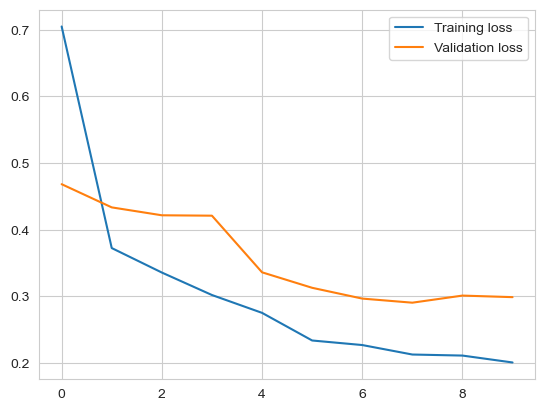

In [397]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:

#from datetime import datetime
trainX = []
trainY = []

t1 = 'xcentre'
t2 = 'ycentre'

T_list = [t2]
target_num = 1

n_future = 1  # Number of days we want to look into the future based on the past days.
n_past = 2

N = n_future + n_past

#Read the csv file
for i, cell in enumerate(natsorted((Path(r'C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data').iterdir()))):
    if i < 100 :
        redex = [t2]
        df = pd.read_csv(cell)
        #print(cell)  #7 columns, including the Date.
         
        if df.shape[0] > N:
            print(cell)
#Separate dates for future plotting
#train_times = pd.to_datetime(df['time']).dt.time
#print(train_times.tail(15))  #Check last few dates.
            for j in list(df)[1:]:
                if j != t2:
                    redex.append(j)
                else:
                    continue
            
            df = df.reindex(
                columns=redex)
            #Variables for training
            cols = list(df)
            #Date and volume columns are not used in training.
            # print(cols)  #['Open', 'High', 'Low', 'Close', 'Adj Close']
            #New dataframe with only training data - 5 columns
            
            df_for_training = df[cols].astype(float).round(decimals=2)
         
            # df_for_plot=df_for_training.tail(5000)
            # df_for_plot.plot.line()
            
            #LSTM uses sigmoid and tanh that are sensitive to magnitude so values need to be normalized
            # normalize the dataset
            scaler = StandardScaler()
            scaler = scaler.fit(df_for_training)
            df_for_training_scaled = scaler.transform(df_for_training)
            #print(df_for_training_scaled)
            
            #As required for LSTM networks, we require to reshape an input data into n_samples x timesteps x n_features.
            #In this example, the n_features is 5. We will make timesteps = 14 (past days data used for training).
            
            #Empty lists to be populated using formatted training data
            
            
  # Number of past days we want to use to predict the future.
            
            #Reformat input data into a shape: (n_samples x timesteps x n_features)
            #In my example, my df_for_training_scaled has a shape (12823, 5)
            #12823 refers to the number of data points and 5 refers to the columns (multi-variables).
            for i in range(n_past, len(df_for_training_scaled) - n_future):
                trainX.append(df_for_training_scaled[i - n_past:i, 0:df_for_training.shape[1]])
                trainY.append(df_for_training_scaled[i + n_future - 1:i + n_future, 0]) #encodes number of targets in Y dataset
                        
        else:
            continue
   
   
#print(df_for_training_scaled)        
# trainX, trainY = np.array(trainX), np.array(trainY)
X_train, X_test, y_train, y_test = train_test_split(trainX, trainY, test_size =1, random_state=16)
X_train, X_test, y_train, y_test = np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test)


print('X_train shape == {}.'.format(X_train.shape))
print('y_train shape == {}.'.format(y_train.shape))

print('X_test shape == {}.'.format(X_test.shape))
print('y_test shape == {}.'.format(y_test.shape))

#In my case, trainX has a shape (12809, 14, 5).
        #12809 because we are looking back 14 days (12823 - 14 = 12809).
        #Remember that we cannot look back 14 days until we get to the 15th day.
        #Also, trainY has a shape (12809, 1). Our model only predicts a single value, but
        #it needs multiple variables (5 in my example) to make this prediction.
        #This is why we can only predict a single day after our training, the day after where our data ends.
        #To predict more days in future, we need all the 5 variables which we do not have.
        #We need to predict all variables if we want to do that.